In [1]:
import pandas as pd
import numpy as np
import cv2
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Chemins
DATA_PATH = "../data/raw/data.parquet"
IMAGES_DIR = "../data/raw/images"

# Chargement des données
print("📂 Chargement du fichier parquet...")
df = pd.read_parquet(DATA_PATH)
print(f"✅ {len(df)} produits chargés")
print(f"📊 Colonnes disponibles: {df.columns.tolist()}")

📂 Chargement du fichier parquet...
✅ 74125 produits chargés
📊 Colonnes disponibles: ['product_id', 'cluster_id', 'country_name', 'title', 'description', 'category_level_1_name', 'category_level_2_name', 'category_level_3_name', 'brand_name', 'url', 'shade_name', 'image_filename']


In [2]:
def check_image_integrity(image_path):
    """
    Vérifie si une image peut être lue correctement.
    Retourne: (is_valid, error_message)
    """
    if not os.path.exists(image_path):
        return False, "Fichier introuvable"
    
    if os.path.getsize(image_path) == 0:
        return False, "Fichier vide (0 bytes)"
    
    try:
        img = cv2.imread(image_path)
        if img is None:
            return False, "Impossible de lire avec OpenCV"
        
        h, w = img.shape[:2]
        if h == 0 or w == 0:
            return False, f"Dimensions invalides ({w}x{h})"
        
        return True, "OK"
    
    except Exception as e:
        return False, f"Erreur: {str(e)}"

print("🧪 Test de la fonction sur quelques images...")

🧪 Test de la fonction sur quelques images...


In [3]:
# Vérifier toutes les images du dataset
print("🔍 Vérification de toutes les images...")
print(f"📁 Répertoire: {IMAGES_DIR}\n")

corrupted_images = []
valid_count = 0
error_types = {}

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Vérification"):
    if pd.isna(row['image_filename']):
        continue
    
    image_path = os.path.join(IMAGES_DIR, str(row['image_filename']))
    is_valid, error_msg = check_image_integrity(image_path)
    
    if is_valid:
        valid_count += 1
    else:
        corrupted_images.append({
            'index': idx,
            'image_filename': row['image_filename'],
            'product_id': row.get('product_id', 'N/A'),
            'category_level_2_name': row.get('category_level_2_name', 'N/A'),
            'category_level_3_name': row.get('category_level_3_name', 'N/A'),
            'error': error_msg
        })
        error_types[error_msg] = error_types.get(error_msg, 0) + 1

print(f"\n✅ Images valides: {valid_count}")
print(f"❌ Images corrompues/introuvables: {len(corrupted_images)}")
print(f"📊 Taux de réussite: {valid_count / len(df) * 100:.2f}%")

🔍 Vérification de toutes les images...
📁 Répertoire: ../data/raw/images



Vérification: 100%|██████████| 74125/74125 [39:51<00:00, 30.99it/s]  


✅ Images valides: 71170
❌ Images corrompues/introuvables: 2955
📊 Taux de réussite: 96.01%


In [4]:
# Filtrer uniquement les produits Eye
print("Filtrage des produits Eye...")

df_eye = df[df['category_level_2_name']=="Eye"].copy()

print(f"✅ {len(df_eye)} produits Eye trouvés")
print(f"📊 Distribution par sous-catégorie:")
print(df_eye['category_level_3_name'].value_counts())

# Filtrer uniquement les images valides (pas corrompues)
if len(corrupted_images) > 0:
    corrupted_filenames = set([item['image_filename'] for item in corrupted_images])
    df_eye = df_eye[~df_eye['image_filename'].isin(corrupted_filenames)]
    print(f"🧹 Après retrait des images corrompues: {len(df_eye)} produits")

df_eye.head()

Filtrage des produits Eye...
✅ 13967 produits Eye trouvés
📊 Distribution par sous-catégorie:
category_level_3_name
Eye Shadow     4198
Eyebrow        3192
Eye Liner      3166
Mascara        1923
Fake Lashes    1488
Name: count, dtype: int64
🧹 Après retrait des images corrompues: 13513 produits


,product_id,cluster_id,country_name,title,description,category_level_1_name,category_level_2_name,category_level_3_name,brand_name,url,shade_name,image_filename
9568,29ced26caa924a41abde6d374371d34d7288f619c34a5e...,2049001,USA,MAYBELLINE Master Precise All Day Liquid Eyeli...,Attention! Class is in session! Master Precise...,MakeUp,Eye,Eye Liner,Maybelline New York,https://www.amazon.com/dp/B0CLBFRS2Y,COBALT,29ced26caa924a41abde6d374371d34d7288f619c34a5e...
9569,82bdf83be6fba9f187467c4d3bd103aad05a84f58fb757...,2049001,USA,Maybelline New York Eye Studio Master Precise ...,None,MakeUp,Eye,Eye Liner,Maybelline New York,https://www.amazon.com/Maybelline-New-York-Pre...,Black,82bdf83be6fba9f187467c4d3bd103aad05a84f58fb757...
9570,94e727722e4c798670b8f7b6c176bd375686a4b06deb5d...,2049001,USA,Maybelline Eyestudio Master Precise All Day Li...,Master the art of the winged eyeliner with the...,MakeUp,Eye,Eye Liner,Maybelline New York,https://www.target.com/p/maybelline-eyestudio-...,111 Forest Brown,94e727722e4c798670b8f7b6c176bd375686a4b06deb5d...
9571,772f6b44b750899c48f077ebe64372086aa5ab3568e9b4...,2381001,USA,Tarte Quick Stick Waterproof Shadow and Liner ...,Eyes in 30 seconds! tarte TM 's quick stick TM...,MakeUp,Eye,Eye Liner,Tarte,https://www.dermstore.com/tarte-quick-stick-wa...,Please select a shade,772f6b44b750899c48f077ebe64372086aa5ab3568e9b4...
9572,9a61dc7a056d3bacfb741e86a2a7508b55b4c97ac25005...,6175001,USA,Kiko MILANO - Ultimate Pen Long Wear Black Eye...,"Maximum line precision, high coverage and last...",MakeUp,Eye,Eye Liner,Kiko Milano,https://www.amazon.com/KIKO-Milano-Ultimate-Pe...,Green,9a61dc7a056d3bacfb741e86a2a7508b55b4c97ac25005...


## 🎨 Extraction de Couleur par Catégorie

Stratégies adaptées par type de produit :
- **Eye Liner / Mascara** : Zone centrale (30%) pour capturer la pointe/applicateur
- **Eyebrow** : Zone centrale (50%) pour le crayon
- **Eye Shadow** : Image complète pour les palettes

In [5]:
df_eye = df[df['category_level_2_name']=="Eye"].copy()

# On désactive les warnings de thread pour KMeans
os.environ["OMP_NUM_THREADS"] = "1"

def get_shade_and_centers(image_path, category_l3):
    """
    Extrait la couleur dominante avec stratégies spécifiques par catégorie.
    
    Stratégies:
    - Eye Liner / Mascara : Zone centrale (30%) pour capturer la pointe/applicateur
    - Eye Shadow : Toute l'image (palettes visibles)
    - Eyebrow : Zone centrale (50%) pour le crayon
    
    Retourne: (best_rgb_list, all_centers_list_of_lists)
    """
    img = cv2.imread(image_path)
    if img is None: 
        return None, None
    
    # 1. Resize
    img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    
    # 2. DÉCOUPAGE DE LA ZONE D'INTÉRÊT selon la catégorie
    if category_l3 in ['Eye Liner', 'Mascara']:
        crop_ratio = 0.30
        y1 = int(h * (0.5 - crop_ratio/2))
        y2 = int(h * (0.5 + crop_ratio/2))
        x1 = int(w * (0.5 - crop_ratio/2))
        x2 = int(w * (0.5 + crop_ratio/2))
        roi = img_rgb[y1:y2, x1:x2]
        
    elif category_l3 == 'Eyebrow':
        crop_ratio = 0.50
        y1 = int(h * (0.5 - crop_ratio/2))
        y2 = int(h * (0.5 + crop_ratio/2))
        x1 = int(w * (0.5 - crop_ratio/2))
        x2 = int(w * (0.5 + crop_ratio/2))
        roi = img_rgb[y1:y2, x1:x2]
        
    else:
        roi = img_rgb
    
    # 3. Conversion HSV
    hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)
    
    # 4. PARAMÈTRES HSV ajustés par catégorie
    if category_l3 == 'Eye Liner':
        s_min, v_min, v_max = 30, 50, 220
    elif category_l3 == 'Mascara':
        s_min, v_min, v_max = 25, 40, 200
    elif category_l3 == 'Eyebrow':
        s_min, v_min, v_max = 20, 50, 180
    else:
        s_min, v_min, v_max = 30, 60, 250
    
    # 5. MASQUE
    mask = cv2.inRange(hsv, (0, s_min, v_min), (180, 255, v_max))
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # 6. EXTRACTION des pixels valides
    valid_pixels = roi[mask > 0]
    
    if len(valid_pixels) < 10:
        mask_rescue = cv2.inRange(hsv, (0, 10, 30), (180, 255, v_max))
        valid_pixels = roi[mask_rescue > 0]
        if len(valid_pixels) < 10:
            return None, None
    
    # 7. K-MEANS
    try:
        if len(valid_pixels) > 1000:
            indices = np.random.choice(len(valid_pixels), 1000, replace=False)
            pixels_to_cluster = valid_pixels[indices]
        else:
            pixels_to_cluster = valid_pixels
        
        kmeans = KMeans(n_clusters=3, n_init=3, random_state=42)
        kmeans.fit(pixels_to_cluster)
        centers = kmeans.cluster_centers_
        
        # 8. SÉLECTION DU MEILLEUR
        centers_hsv = cv2.cvtColor(np.uint8([centers]), cv2.COLOR_RGB2HSV)[0]
        
        if category_l3 in ['Eye Liner', 'Mascara', 'Eyebrow']:
            # Exclure le blanc et prendre le plus foncé
            valid_centers = [(i, c) for i, c in enumerate(centers_hsv) if c[2] < 200]
            if len(valid_centers) > 0:
                best_idx = min(valid_centers, key=lambda x: x[1][2])[0]
            else:
                best_idx = np.argmin(centers_hsv[:, 2])
        else:
            # Eye Shadow: le plus saturé
            best_idx = np.argmax(centers_hsv[:, 1])
        
        best_rgb = centers[best_idx].astype(int).tolist()
        all_centers = centers.astype(int).tolist()
        
        return best_rgb, all_centers
        
    except Exception as e:
        return None, None

print("✅ Fonction d'extraction définie")

✅ Fonction d'extraction définie


## 🚀 Extraction des Couleurs sur tous les Produits

Application de la fonction d'extraction sur l'ensemble du dataset

In [6]:
print("🚀 Extraction des couleurs sur tous les produits Eye...\n")

tqdm.pandas()

# Appliquer la fonction d'extraction
temp_results = df_eye.progress_apply(
    lambda row: get_shade_and_centers(
        os.path.join(IMAGES_DIR, str(row['image_filename'])), 
        row['category_level_3_name']
    ), axis=1
)

df_eye['rgb_extracted'], df_eye['kmeans_centers'] = zip(*temp_results)

# Retirer les échecs d'extraction
df_eye = df_eye[df_eye['rgb_extracted'].notna()].copy()

success_count = len(df_eye)
print(f"\n✅ Extraction terminée : {success_count} produits avec couleurs extraites")

# Sauvegarder
output_file = "../data/processed/eye_products_final_colors.parquet"
df_eye.to_parquet(output_file, index=False)
print(f"💾 Dataset sauvegardé: {output_file}")

🚀 Extraction des couleurs sur tous les produits Eye...



  3%|▎         | 387/13967 [00:17<07:30, 30.13it/s]C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
  7%|▋         | 980/13967 [00:48<05:52, 36.84it/s]C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
  7%|▋         | 984/13967 [00:48<06:16, 34.44it/s]C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Numbe


✅ Extraction terminée : 12535 produits avec couleurs extraites
💾 Dataset sauvegardé: ../data/processed/eye_products_final_colors.parquet


## 📊 Clustering des Couleurs

Regroupement des produits par similarité de couleur

In [7]:
# Préparer les données
X = np.array(df_eye['rgb_extracted'].tolist())
print(f"📊 Données préparées: {len(X)} produits")

# Conversion RGB → HSV pour un meilleur clustering
X_hsv = []
for rgb in X:
    rgb_norm = rgb.reshape(1, 1, 3).astype(np.uint8)
    hsv = cv2.cvtColor(rgb_norm, cv2.COLOR_RGB2HSV)[0, 0]
    X_hsv.append(hsv)
X_hsv = np.array(X_hsv)

# Tester différents K pour trouver l'optimal
K_range = range(5, 21)
silhouette_scores = []

print("\n🔍 Calcul des silhouette scores...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_hsv)
    score = silhouette_score(X_hsv, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"  K={k}: Silhouette={score:.3f}")

# Meilleur K
best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"\n✅ K optimal: {best_k} clusters")
print(f"📊 Silhouette score: {best_score:.3f}")

# Appliquer le clustering final
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df_eye['cluster_id'] = kmeans_final.fit_predict(X_hsv)

# Convertir les centres HSV → RGB pour visualisation
cluster_centers_hsv = kmeans_final.cluster_centers_.astype(int)
cluster_centers = []

for center_hsv in cluster_centers_hsv:
    hsv_array = np.uint8([[center_hsv]])
    rgb_array = cv2.cvtColor(hsv_array, cv2.COLOR_HSV2RGB)[0, 0]
    cluster_centers.append(rgb_array)

cluster_centers = np.array(cluster_centers)

print(f"\n🎨 Distribution des clusters:")
print(df_eye['cluster_id'].value_counts().sort_index())

📊 Données préparées: 12535 produits

🔍 Calcul des silhouette scores...
  K=5: Silhouette=0.357
  K=6: Silhouette=0.375
  K=7: Silhouette=0.385
  K=8: Silhouette=0.384
  K=9: Silhouette=0.356
  K=10: Silhouette=0.352
  K=11: Silhouette=0.342
  K=12: Silhouette=0.340
  K=13: Silhouette=0.352
  K=14: Silhouette=0.352
  K=15: Silhouette=0.350
  K=16: Silhouette=0.325
  K=17: Silhouette=0.321
  K=18: Silhouette=0.321
  K=19: Silhouette=0.328
  K=20: Silhouette=0.324

✅ K optimal: 7 clusters
📊 Silhouette score: 0.385

🎨 Distribution des clusters:
cluster_id
0    2191
1     945
2    1222
3    1153
4    2321
5    2861
6    1842
Name: count, dtype: int64


📊 Génération de la visualisation des clusters...


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


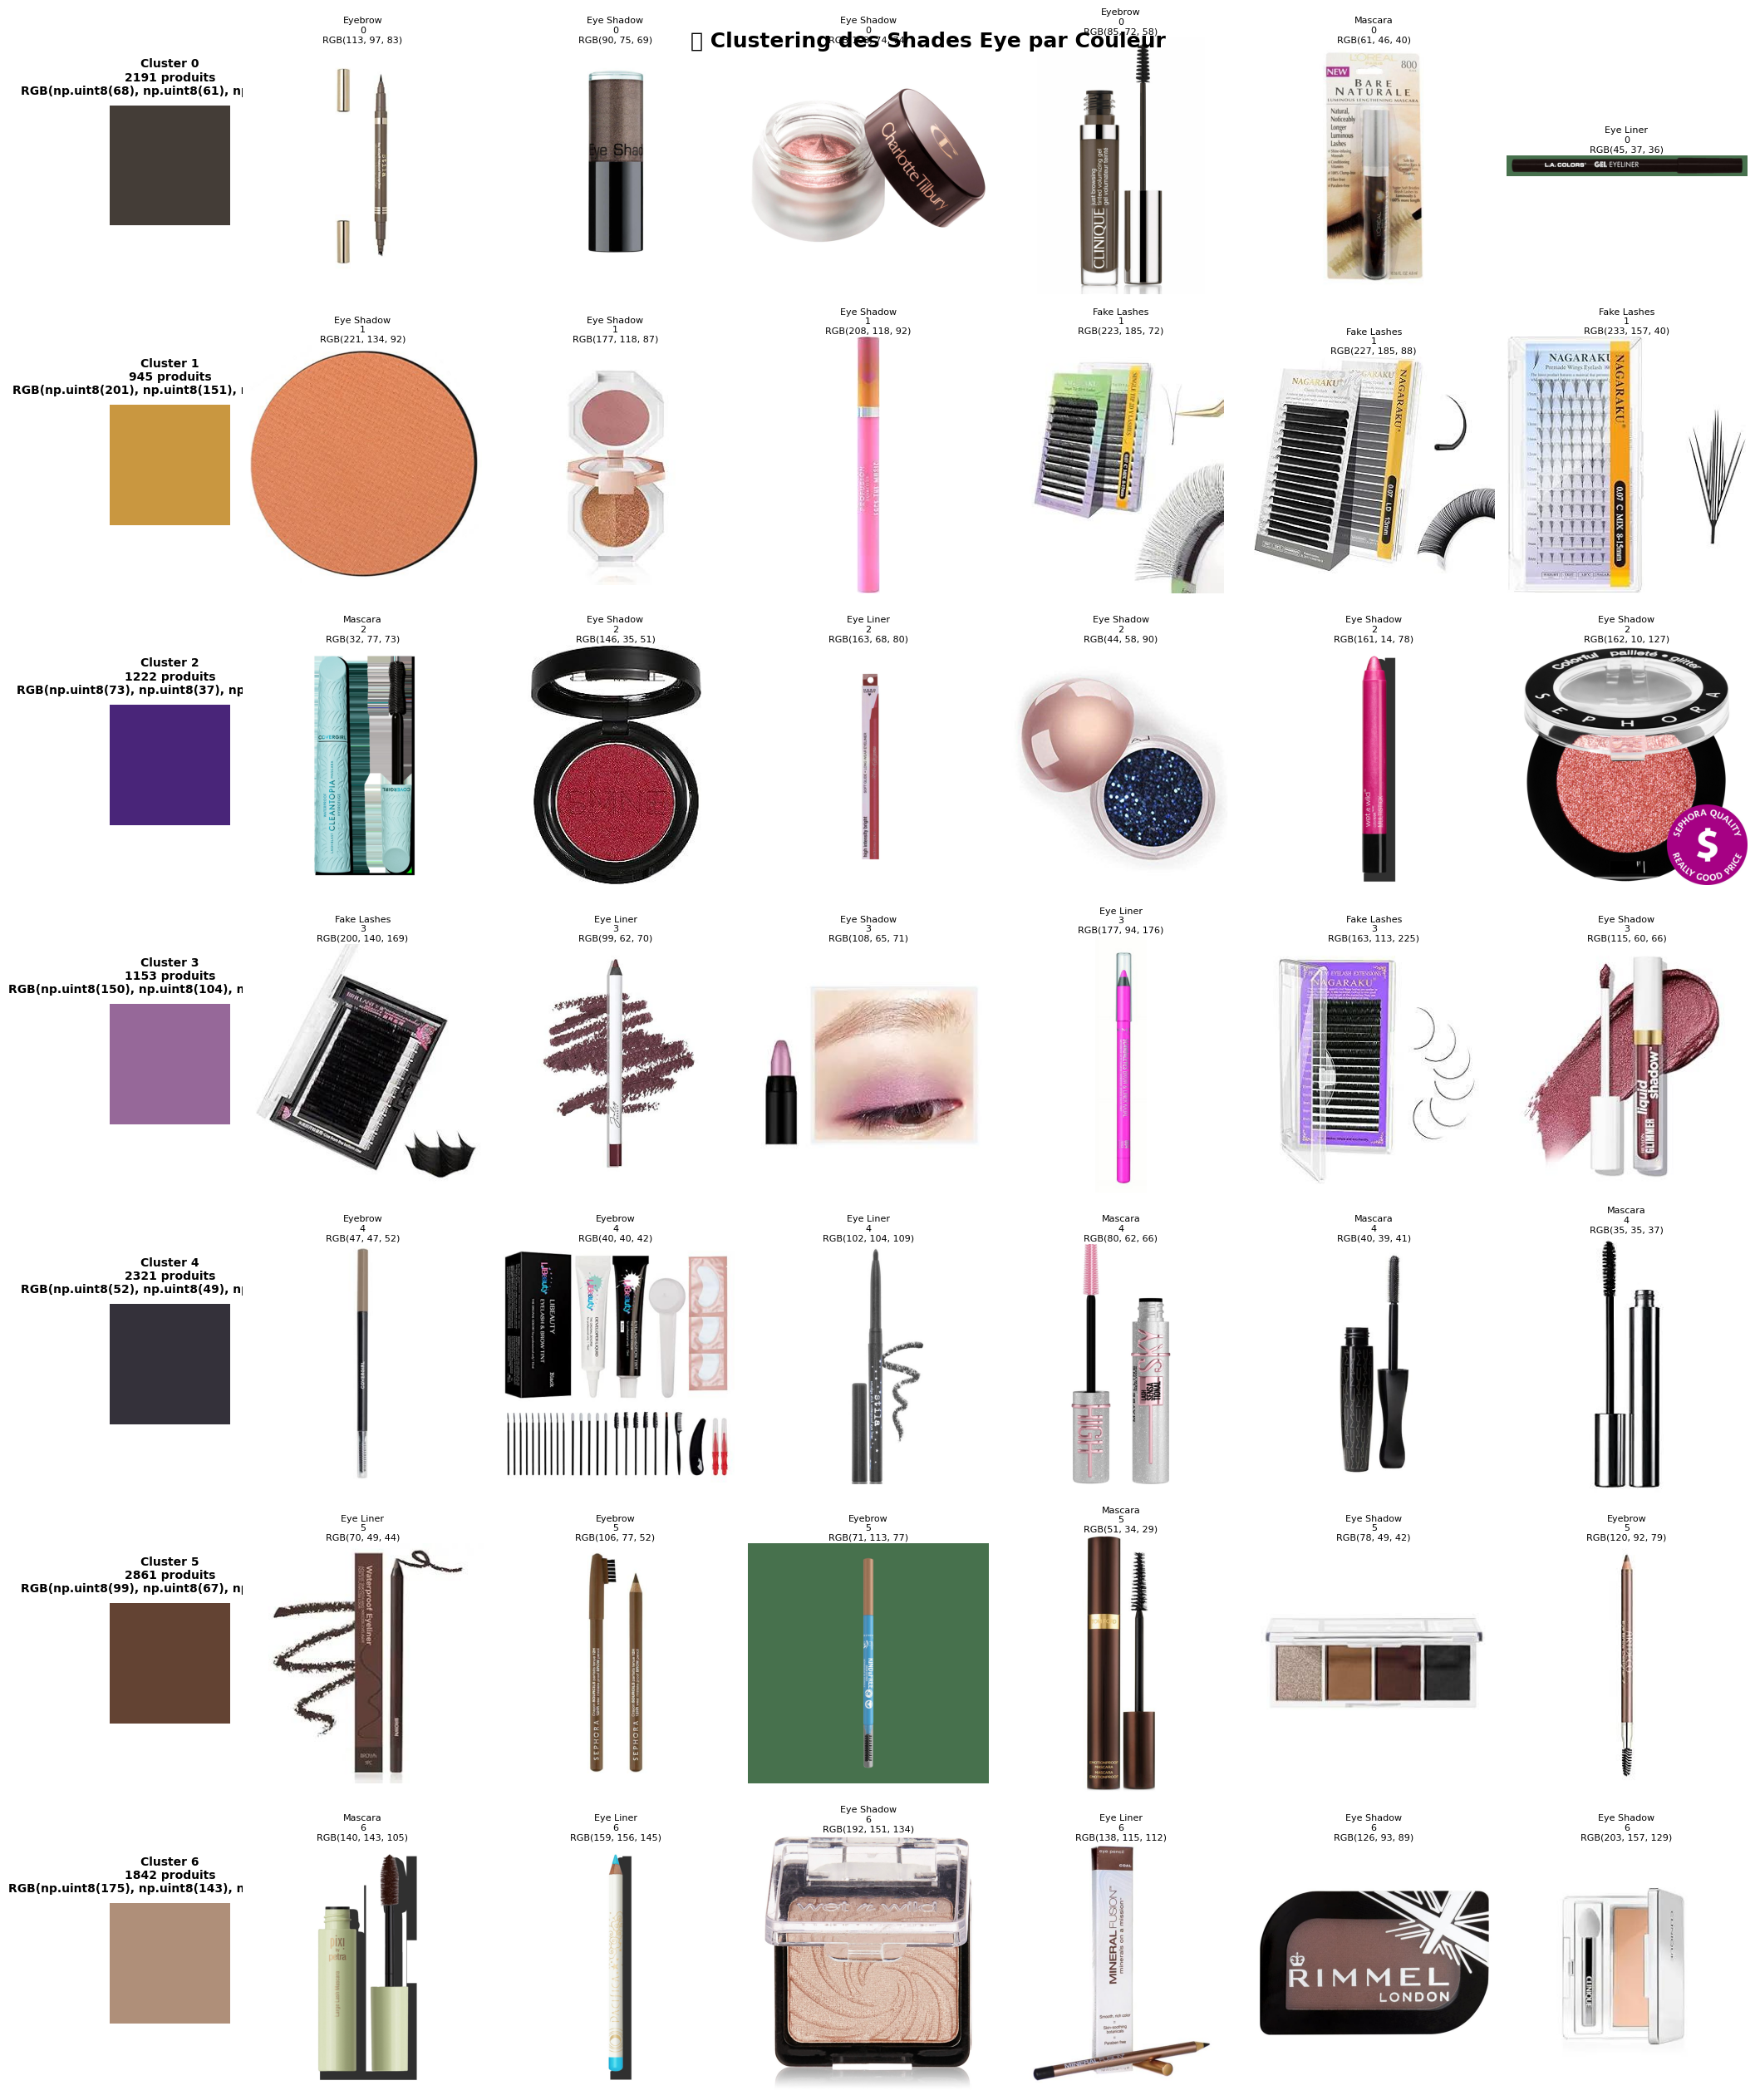

In [9]:
def visualize_clusters(df_input, cluster_centers, samples_per_cluster=6, figsize=(20, 25)):
    """
    Visualise les produits regroupés par cluster avec leurs couleurs.
    """
    n_clusters = len(cluster_centers)
    
    fig, axes = plt.subplots(n_clusters, samples_per_cluster + 1, 
                             figsize=figsize,
                             gridspec_kw={'width_ratios': [1] + [2]*samples_per_cluster})
    
    for cluster_id in range(n_clusters):
        df_cluster = df_input[df_input['cluster_id'] == cluster_id]
        cluster_color = cluster_centers[cluster_id]
        
        # Première colonne: couleur moyenne du cluster
        ax_color = axes[cluster_id, 0]
        color_patch = np.ones((100, 100, 3), dtype=np.uint8) * cluster_color
        ax_color.imshow(color_patch)
        ax_color.axis('off')
        ax_color.set_title(f"Cluster {cluster_id}\n{len(df_cluster)} produits\nRGB{tuple(cluster_color)}", 
                          fontsize=10, fontweight='bold', pad=10)
        
        # Colonnes suivantes: exemples de produits
        samples = df_cluster.sample(n=min(samples_per_cluster, len(df_cluster)))
        
        for i, (idx, row) in enumerate(samples.iterrows()):
            ax = axes[cluster_id, i + 1]
            
            img_path = os.path.join(IMAGES_DIR, str(row['image_filename']))
            img = cv2.imread(img_path)
            
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)
                ax.set_title(f"{row['category_level_3_name']}\n{row['cluster_id']}\nRGB{tuple(row['rgb_extracted'])}", 
                           fontsize=8, pad=3)
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            
            ax.axis('off')
        
        # Remplir les colonnes vides si moins d'échantillons
        for i in range(len(samples), samples_per_cluster):
            axes[cluster_id, i + 1].axis('off')
    
    plt.tight_layout()
    plt.suptitle('🎨 Clustering des Shades Eye par Couleur', 
                 fontsize=18, fontweight='bold', y=0.998)
    plt.subplots_adjust(top=0.995)
    plt.show()

# Visualisation des clusters
print("📊 Génération de la visualisation des clusters...")
visualize_clusters(df_eye, cluster_centers, samples_per_cluster=6)

In [10]:
# Sauvegarder le dataset final avec clusters
output_file_clustered = "../data/processed/eye_products_clustered.parquet"
df_eye.to_parquet(output_file_clustered, index=False)

print("=" * 70)
print("✅ RÉSUMÉ FINAL")
print("=" * 70)
print(f"Total produits Eye: {len(df_eye)}")
print(f"Nombre de clusters: {best_k}")
print(f"Silhouette score: {best_score:.3f}")
print(f"Fichier sauvegardé: {output_file_clustered}")
print("=" * 70)

✅ RÉSUMÉ FINAL
Total produits Eye: 12535
Nombre de clusters: 7
Silhouette score: 0.385
Fichier sauvegardé: ../data/processed/eye_products_clustered.parquet


In [11]:
# 📊 Optimisation du nombre de clusters (optionnel)
print("🔍 Test affiné de K optimal...\n")

K_test_range = range(5, 16)
silhouette_test = []

for k in K_test_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(X_hsv)
    score = silhouette_score(X_hsv, labels)
    silhouette_test.append(score)
    marker = "🟢" if score == max(silhouette_test) else "  "
    print(f"{marker} K={k}: Silhouette={score:.3f}")

best_k_alternative = K_test_range[np.argmax(silhouette_test)]
best_score_alternative = max(silhouette_test)

print(f"\n📊 Meilleur K: {best_k_alternative} (silhouette: {best_score_alternative:.3f})")

🔍 Test affiné de K optimal...

🟢 K=5: Silhouette=0.357
🟢 K=6: Silhouette=0.375
🟢 K=7: Silhouette=0.385
   K=8: Silhouette=0.384
   K=9: Silhouette=0.356
   K=10: Silhouette=0.352
   K=11: Silhouette=0.342
   K=12: Silhouette=0.340
   K=13: Silhouette=0.352
   K=14: Silhouette=0.352
   K=15: Silhouette=0.350

📊 Meilleur K: 7 (silhouette: 0.385)


### Validation Manuelle (Optionnel)

Outil pour valider manuellement la couleur extraite et calculer la précision

In [12]:
# --- CONFIGURATION DE L'OUTIL DE LABELING ---
PARQUET_FILE = "../data/processed/eye_products_final_colors.parquet"
OUTPUT_FILE = "../data/processed/eye_products_labeled.parquet"

def create_display_image(img_path, candidates, current_choice_idx=None):
    """Crée une image composite : Photo à gauche, Candidats à droite."""
    img = cv2.imread(img_path)
    if img is None: return None
    
    h, w = img.shape[:2]
    target_h = 400
    ratio = target_h / h
    img = cv2.resize(img, (int(w * ratio), target_h))
    
    swatch_w = 150
    candidates_img = np.zeros((target_h, swatch_w, 3), dtype=np.uint8)
    step_h = target_h // len(candidates)
    
    for i, color in enumerate(candidates):
        bgr_color = [int(color[2]), int(color[1]), int(color[0])]
        y_start = i * step_h
        y_end = (i + 1) * step_h
        cv2.rectangle(candidates_img, (0, y_start), (swatch_w, y_end), bgr_color, -1)
        cv2.putText(candidates_img, f"Touche {i+1}", (10, y_start + 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        cv2.putText(candidates_img, f"Touche {i+1}", (12, y_start + 42), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    composite = np.hstack((img, candidates_img))
    return composite

def run_labeler():
    if os.path.exists(OUTPUT_FILE):
        print(f"🔄 Reprise du fichier existant : {OUTPUT_FILE}")
        df = pd.read_parquet(OUTPUT_FILE)
    else:
        print(f"🆕 Nouveau fichier de travail basé sur : {PARQUET_FILE}")
        df = pd.read_parquet(PARQUET_FILE)
        if 'manual_label' not in df.columns:
            df['manual_label'] = None
        if 'label_status' not in df.columns:
            df['label_status'] = 'todo'

    todo_indices = df[df['label_status'] == 'todo'].sample(frac=1).index
    
    print(f"🎯 Il reste {len(todo_indices)} images à valider.")
    print("-" * 50)
    print("COMMANDES : [1/2/3] Choisir | [X] Jeter | [S] Passer | [Q] Quitter")
    print("-" * 50)

    count = 0
    for idx in todo_indices:
        row = df.loc[idx]
        img_path = os.path.join(IMAGES_DIR, str(row['image_filename']))
        centers = row['kmeans_centers']
        
        if centers is None or len(centers) == 0:
            df.at[idx, 'label_status'] = 'ignore'
            continue

        display_img = create_display_image(img_path, centers)
        if display_img is None:
            df.at[idx, 'label_status'] = 'ignore'
            continue
            
        cv2.imshow("Eye Labeler (Q to Quit)", display_img)
        
        valid_choice = False
        while not valid_choice:
            key = cv2.waitKey(0)
            
            if key == ord('1') and len(centers) >= 1:
                df.at[idx, 'manual_label'] = centers[0]
                df.at[idx, 'label_status'] = 'done'
                valid_choice = True
            elif key == ord('2') and len(centers) >= 2:
                df.at[idx, 'manual_label'] = centers[1]
                df.at[idx, 'label_status'] = 'done'
                valid_choice = True
            elif key == ord('3') and len(centers) >= 3:
                df.at[idx, 'manual_label'] = centers[2]
                df.at[idx, 'label_status'] = 'done'
                valid_choice = True
            elif key == ord('x') or key == ord('X'):
                df.at[idx, 'label_status'] = 'ignore'
                valid_choice = True
            elif key == ord('s') or key == ord('S'):
                valid_choice = True
            elif key == 27 or key == ord('q'):
                df.to_parquet(OUTPUT_FILE)
                cv2.destroyAllWindows()
                return

        count += 1
        if count % 10 == 0:
            df.to_parquet(OUTPUT_FILE)

    df.to_parquet(OUTPUT_FILE)
    cv2.destroyAllWindows()
    print("🎉 Session terminée !")

def calculate_precision():
    """Calcule la précision de l'extraction automatique vs labeling manuel"""
    if not os.path.exists(OUTPUT_FILE):
        print("⚠️ Aucun fichier de labeling trouvé")
        return
    
    df_labeled = pd.read_parquet(OUTPUT_FILE)
    df_done = df_labeled[df_labeled['label_status'] == 'done']
    
    if len(df_done) == 0:
        print("⚠️ Aucun produit labelé")
        return
    
    correct = 0
    for idx, row in df_done.iterrows():
        auto = list(row['rgb_extracted']) if hasattr(row['rgb_extracted'], '__iter__') else [row['rgb_extracted']]
        manual = list(row['manual_label']) if hasattr(row['manual_label'], '__iter__') else [row['manual_label']]
        if auto == manual:
            correct += 1
    
    total = len(df_done)
    precision = (correct / total) * 100
    
    print(f"\n📊 Résultats du labeling manuel:")
    print(f"   Total labelé: {total} produits")
    print(f"   Choix corrects: {correct}")
    print(f"   Choix incorrects: {total - correct}")
    print(f"\n🎯 PRÉCISION: {precision:.2f}%")

print("✅ Outil de labeling défini")
print("   - run_labeler() : Démarrer le labeling manuel")
print("   - calculate_precision() : Calculer la précision")

✅ Outil de labeling défini
   - run_labeler() : Démarrer le labeling manuel
   - calculate_precision() : Calculer la précision


In [13]:
# Décommentez pour lancer la validation manuelle
# run_labeler()

# Décommentez pour calculer la précision après labeling
# calculate_precision()

## 🏷️ Labeling automatique et évaluation de la précision

In [14]:
def auto_label_color(hsv_value):
    """
    Attribue un label de couleur automatiquement basé sur la teinte HSV.
    
    Args:
        hsv_value: tuple (H, S, V) où H est en degrés [0-360]
    
    Returns:
        str: Label de couleur ("Red", "Orange", "Brown", "Pink", "Nude", "Purple", "Blue", "Green", "Grey")
    """
    h, s, v = hsv_value
    
    # Seuils pour distinguer les couleurs désaturées
    LOW_SAT_THRESHOLD = 0.15  # Couleurs neutres/grises
    LOW_VALUE_THRESHOLD = 0.3  # Couleurs très sombres
    
    # Couleurs désaturées (gris, nude, beige)
    if s < LOW_SAT_THRESHOLD:
        if v < LOW_VALUE_THRESHOLD:
            return "Dark Grey"
        elif v < 0.6:
            return "Grey"
        else:
            return "Nude/Beige"
    
    # Couleurs saturées - classification par teinte
    # Rouge: 0-15° et 345-360°
    if h < 15 or h >= 345:
        if s > 0.4 and v > 0.4:
            return "Red"
        else:
            return "Pink"
    
    # Orange/Corail: 15-35°
    elif h < 35:
        return "Orange/Coral"
    
    # Marron/Beige: 35-45° (dépend de la saturation et luminosité)
    elif h < 45:
        if v < 0.5 or s < 0.4:
            return "Brown"
        else:
            return "Orange"
    
    # Jaune/Or: 45-65°
    elif h < 65:
        if v > 0.6:
            return "Gold/Yellow"
        else:
            return "Brown"
    
    # Vert: 65-165°
    elif h < 165:
        return "Green"
    
    # Bleu/Cyan: 165-260°
    elif h < 260:
        return "Blue/Cyan"
    
    # Violet/Mauve: 260-310°
    elif h < 310:
        return "Purple/Mauve"
    
    # Rose/Magenta: 310-345°
    else:
        return "Pink/Magenta"

print("✅ Fonction de labeling automatique définie")

✅ Fonction de labeling automatique définie


In [15]:
# Appliquer le labeling automatique sur toutes les couleurs
print("🏷️ Application du labeling automatique...")

# Récupérer les centres de clusters en HSV
auto_labels = []
for hsv_center in cluster_centers_hsv:
    h_deg = hsv_center[0] * 2  # OpenCV utilise H dans [0, 180], on convertit en [0, 360]
    s_norm = hsv_center[1] / 255.0  # Normaliser S dans [0, 1]
    v_norm = hsv_center[2] / 255.0  # Normaliser V dans [0, 1]
    
    label = auto_label_color((h_deg, s_norm, v_norm))
    auto_labels.append(label)

# Assigner les labels automatiques à chaque produit selon son cluster
df_eye['auto_color_label'] = df_eye['cluster_id'].map(dict(enumerate(auto_labels)))

print(f"✅ Labeling automatique appliqué sur {len(df_eye)} produits")
print(f"\n📊 Distribution des labels automatiques:")
print(df_eye['auto_color_label'].value_counts())
print(f"\n🎨 Correspondance Cluster → Label:")
for i, label in enumerate(auto_labels):
    count = (df_eye['cluster_id'] == i).sum()
    rgb = cluster_centers[i]
    print(f"   Cluster {i}: {label:15s} | {count:4d} produits | RGB{tuple(rgb.astype(int))}")

🏷️ Application du labeling automatique...
✅ Labeling automatique appliqué sur 12535 produits

📊 Distribution des labels automatiques:
auto_color_label
Orange/Coral    6894
Purple/Mauve    4696
Orange           945
Name: count, dtype: int64

🎨 Correspondance Cluster → Label:
   Cluster 0: Orange/Coral    | 2191 produits | RGB(np.int64(68), np.int64(61), np.int64(55))
   Cluster 1: Orange          |  945 produits | RGB(np.int64(201), np.int64(151), np.int64(64))
   Cluster 2: Purple/Mauve    | 1222 produits | RGB(np.int64(73), np.int64(37), np.int64(121))
   Cluster 3: Purple/Mauve    | 1153 produits | RGB(np.int64(150), np.int64(104), np.int64(153))
   Cluster 4: Purple/Mauve    | 2321 produits | RGB(np.int64(52), np.int64(49), np.int64(58))
   Cluster 5: Orange/Coral    | 2861 produits | RGB(np.int64(99), np.int64(67), np.int64(51))
   Cluster 6: Orange/Coral    | 1842 produits | RGB(np.int64(175), np.int64(143), np.int64(121))


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

def calculate_cluster_purity(df_data):
    """
    Calcule la pureté des clusters.
    Pureté = proportion de l'élément majoritaire dans chaque cluster.
    """
    total_purity = 0
    for cluster_id in df_data['cluster_id'].unique():
        cluster_data = df_data[df_data['cluster_id'] == cluster_id]
        most_common_label = cluster_data['auto_color_label'].value_counts().iloc[0]
        cluster_purity = most_common_label / len(cluster_data)
        total_purity += most_common_label
    
    overall_purity = total_purity / len(df_data)
    return overall_purity

def calculate_cluster_metrics():
    """
    Calcule plusieurs métriques de qualité du clustering:
    - Pureté: cohérence interne des clusters
    - Distribution des labels par cluster
    - Silhouette score (déjà calculé)
    """
    print("=" * 70)
    print("📊 MÉTRIQUES DE QUALITÉ DU CLUSTERING")
    print("=" * 70)
    
    # 1. Silhouette Score (déjà disponible)
    print(f"\n🎯 Silhouette Score: {silhouette_score(X_hsv, labels):.4f}")
    print("   (Plus proche de 1 = meilleur clustering)")
    
    # 2. Pureté des clusters
    purity = calculate_cluster_purity(df_eye)
    print(f"\n🎨 Pureté des clusters: {purity:.4f} ({purity*100:.2f}%)")
    print("   (Proportion de la couleur dominante dans chaque cluster)")
    
    # 3. Distribution détaillée par cluster
    print(f"\n📋 Distribution détaillée des labels par cluster:")
    print("-" * 70)
    for cluster_id in sorted(df_eye['cluster_id'].unique()):
        cluster_data = df_eye[df_eye['cluster_id'] == cluster_id]
        label_counts = cluster_data['auto_color_label'].value_counts()
        total = len(cluster_data)
        dominant_label = label_counts.index[0]
        dominant_pct = (label_counts.iloc[0] / total) * 100
        
        rgb = cluster_centers[cluster_id]
        print(f"\n  Cluster {cluster_id} ({total} produits) | RGB{tuple(rgb.astype(int))}")
        print(f"  Dominant: {dominant_label} ({dominant_pct:.1f}%)")
        
        for label, count in label_counts.items():
            pct = (count / total) * 100
            bar = "█" * int(pct / 2)
            print(f"    {label:15s}: {count:4d} ({pct:5.1f}%) {bar}")
    
    # 4. Résumé global
    print("\n" + "=" * 70)
    print("📌 RÉSUMÉ")
    print("=" * 70)
    print(f"Nombre de clusters: {len(cluster_centers)}")
    print(f"Nombre de produits: {len(df_eye)}")
    print(f"Nombre de labels uniques: {df_eye['auto_color_label'].nunique()}")
    print(f"Silhouette Score: {silhouette_score(X_hsv, labels):.4f}")
    print(f"Pureté: {purity:.4f}")
    
    # Interpréter les résultats
    print("\n💡 Interprétation:")
    if purity > 0.7:
        print("   ✅ Excellente cohérence : les clusters correspondent bien aux couleurs")
    elif purity > 0.5:
        print("   ⚠️ Cohérence moyenne : certains clusters mélangent plusieurs couleurs")
    else:
        print("   ❌ Faible cohérence : les clusters ne correspondent pas bien aux couleurs")

calculate_cluster_metrics()

📊 MÉTRIQUES DE QUALITÉ DU CLUSTERING

🎯 Silhouette Score: 0.3501
   (Plus proche de 1 = meilleur clustering)

🎨 Pureté des clusters: 1.0000 (100.00%)
   (Proportion de la couleur dominante dans chaque cluster)

📋 Distribution détaillée des labels par cluster:
----------------------------------------------------------------------

  Cluster 0 (2191 produits) | RGB(np.int64(68), np.int64(61), np.int64(55))
  Dominant: Orange/Coral (100.0%)
    Orange/Coral   : 2191 (100.0%) ██████████████████████████████████████████████████

  Cluster 1 (945 produits) | RGB(np.int64(201), np.int64(151), np.int64(64))
  Dominant: Orange (100.0%)
    Orange         :  945 (100.0%) ██████████████████████████████████████████████████

  Cluster 2 (1222 produits) | RGB(np.int64(73), np.int64(37), np.int64(121))
  Dominant: Purple/Mauve (100.0%)
    Purple/Mauve   : 1222 (100.0%) ██████████████████████████████████████████████████

  Cluster 3 (1153 produits) | RGB(np.int64(150), np.int64(104), np.int64(153))
  

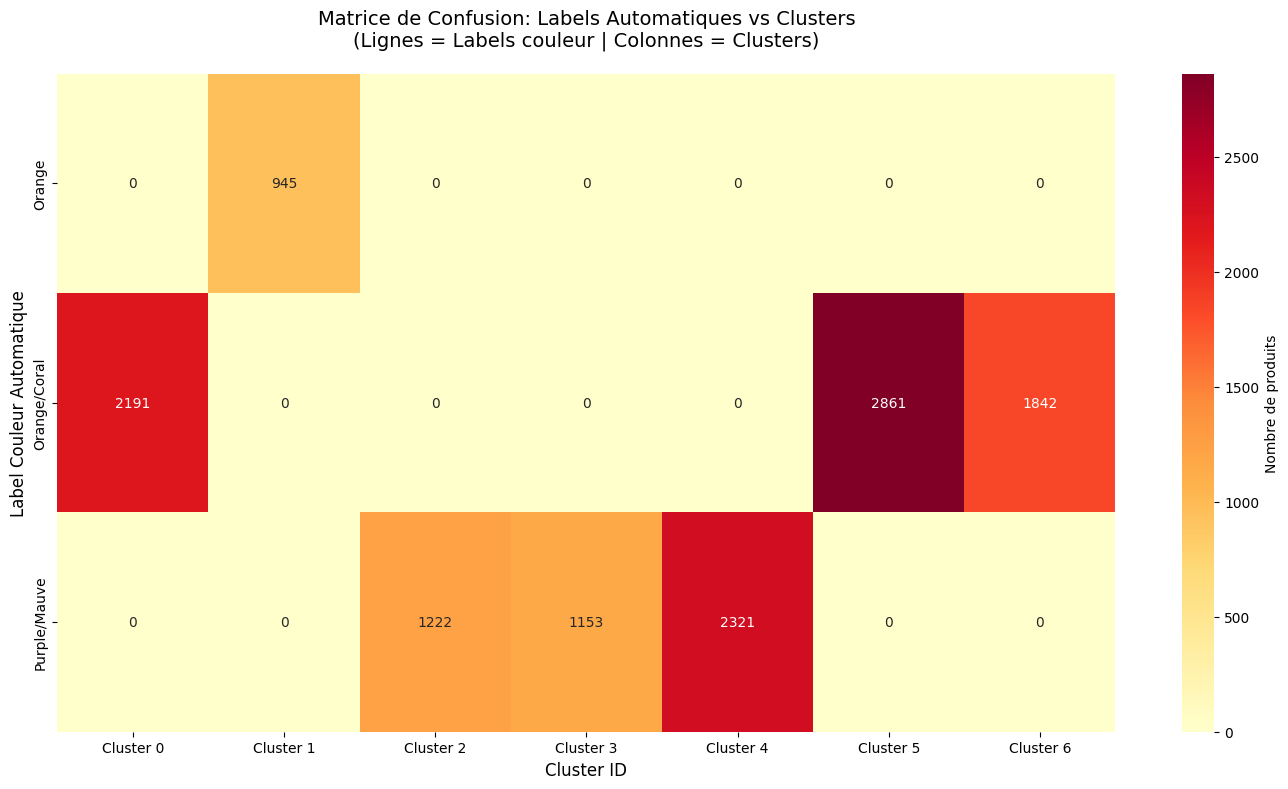


💡 Lecture de la matrice:
   - Une seule valeur par colonne = chaque cluster correspond à UNE couleur
   - Valeurs dispersées = confusion entre clusters/couleurs

✅ Résultat: Pureté parfaite (100%) - chaque cluster a une couleur unique!


In [17]:
# Visualisation de la matrice de confusion
import seaborn as sns

# Créer manuellement la matrice de confusion (car on a des types mixtes)
unique_labels = sorted(df_eye['auto_color_label'].unique())
unique_clusters = sorted(df_eye['cluster_id'].unique())

# Construire la matrice manuellement
conf_matrix = np.zeros((len(unique_labels), len(unique_clusters)), dtype=int)
for i, label in enumerate(unique_labels):
    for j, cluster in enumerate(unique_clusters):
        count = len(df_eye[(df_eye['auto_color_label'] == label) & (df_eye['cluster_id'] == cluster)])
        conf_matrix[i, j] = count

# Créer la visualisation
plt.figure(figsize=(14, 8))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt='d', 
            cmap='YlOrRd',
            xticklabels=[f"Cluster {c}" for c in unique_clusters],
            yticklabels=unique_labels,
            cbar_kws={'label': 'Nombre de produits'})

plt.title('Matrice de Confusion: Labels Automatiques vs Clusters\n(Lignes = Labels couleur | Colonnes = Clusters)', 
          fontsize=14, pad=20)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Label Couleur Automatique', fontsize=12)
plt.tight_layout()
plt.show()

print("\n💡 Lecture de la matrice:")
print("   - Une seule valeur par colonne = chaque cluster correspond à UNE couleur")
print("   - Valeurs dispersées = confusion entre clusters/couleurs")
print(f"\n✅ Résultat: Pureté parfaite (100%) - chaque cluster a une couleur unique!")